# Streaming Sensor Anomaly Detection: Online Detectors, Concept-Drift Gating, and Alert-Fatigue Economics

**The problem.** An on-call engineering team is paged 47 times in a quiet week.  41 of those pages are noise — recovered before anyone logged in, or never represented a real incident.  The remaining six matter, but they arrive **in the same alert stream as the noise**, so the team's median time-to-acknowledge for genuine alerts has crept from 4 minutes to 22 minutes.  The team has implicitly responded by **disabling the chattiest detectors entirely**, which is how a real outage slips by.  This is the **alert-fatigue economy** of any streaming-anomaly system: precision is not a metric, it is a *production cost*.

A useful detector therefore has to satisfy three constraints simultaneously:

1. **Streaming**: it must produce a score for every new point with no leakage from the future.  Sliding windows, online updates, EWMA-style state — all fine.  Test-set partitioning is not.
2. **Calibrated to a budget**: the team has at most $B$ pages a day.  The right detector at $B = 5$ may not be the right detector at $B = 20$.  A precision-at-fixed-recall plot is no longer enough; we need **alert-budget curves**.
3. **Drift-aware**: a level shift caused by deployment, traffic mix change, or sensor recalibration is *not* an anomaly.  Naively-thresholded detectors fire continuously after such shifts; production detectors must **detect the regime change** and rebase.

**The data.** The **Numenta Anomaly Benchmark (NAB)** — the canonical labelled streaming-anomaly corpus.  Each stream is a univariate time series with **hand-labelled anomaly windows** and a published scoring profile (early-detection bonus, late penalty).  Public GitHub, no auth.  We pick **four streams** that cover the production flavours an SRE / IoT team actually deals with:

| stream | source | character |
| --- | --- | --- |
| `nyc_taxi.csv` | NYC TLC | **demand** time series with strong daily / weekly seasonality, marathon spikes, holiday dips |
| `machine_temperature_system_failure.csv` | factory floor | **IoT temperature** with three pre-failure events (planned shutdown, mechanical fault, catastrophic failure) |
| `ec2_cpu_utilization_5f5533.csv` | AWS CloudWatch | **server CPU** with deploy-related shifts and a runaway-load incident |
| `exchange-2_cpc_results.csv` | ad-exchange | **web revenue** time series with bid-mix changes and a known fraud incident |

**The approach.**

1. **Data acquisition** — fetch the four NAB streams + `combined_windows.json` labels with a robust download + cache.
2. **EDA** — per-stream visualisation with labelled anomaly windows highlighted.
3. **Eight detectors with a common `update(t, x) -> score` interface**:
   - **Three-Sigma** on a rolling window.
   - **IQR-on-rolling** — the robust cousin.
   - **EWMA control charts** (Shewhart limits on smoothed mean).
   - **CUSUM** (two-sided cumulative sum).
   - **Sliding-window IsolationForest** — periodic refit on the most recent W points.
   - **Half-Space Trees** (`river.anomaly.HalfSpaceTrees`) — purely online, constant memory.
   - **Online Robust Random-Cut Forest** approximation via incremental scoring (or `river.anomaly.OneClassSVM` fallback).
   - **LSTM autoencoder** — small CPU-only seq2seq trained on a "normal" warm-up window, scoring residuals on the live stream.
4. **Concept-drift gating** — ADWIN and Page-Hinkley change detectors run *in parallel* with each anomaly detector.  When drift fires, the anomaly detector enters a **rebase cooldown** during which it does not raise alerts; instead it re-fits its baseline on the post-drift window.  This is what separates a "score generator" from a *production* detector.
5. **Alert post-processing** — threshold ↦ raw alerts ↦ **cooldown** (suppress alerts within $\Delta$ of a recent alert) ↦ **grouping** (collapse consecutive alerts into one ticket).
6. **Evaluation suite**:
   - **NAB scoring profile** with the standard `(A_TP, A_FP, A_FN)` profile weights.
   - Standard precision / recall / F1 / **time-to-detect**.
   - **Alert-budget curves**: precision vs alerts/day, the curve the SRE manager actually reads.
   - **Cost-aware operating point** with explicit FP : FN ratio (page cost vs missed-incident cost) → recommended threshold per detector.
7. **Champion selection** — per stream and portfolio-wide.  We surface that *no single detector wins everywhere* (this is the right answer; it justifies the ensemble).
8. **Production hygiene** — per-event latency P50/P95, memory footprint, state checkpoint save / reload parity, alert-stream JSONL audit, model card.

**Audience.** SRE / on-call engineers, IoT platform teams, data-science teams shipping monitoring layers, anyone whose detector wakes someone up at night.

## 0. Setup and reproducibility

Seeds fixed; plot defaults match the rest of the portfolio; paths computed relative to the notebook.  All artefacts (cached NAB data, persisted detectors, model card, alert audit log) live under `notebooks/artifacts/streaming_anomaly/`.

In [1]:
from __future__ import annotations

import io
import json
import math
import pathlib
import time
import urllib.request
import warnings
from collections import deque
from dataclasses import dataclass, field
from typing import Callable, Iterable

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.ensemble import IsolationForest

import river
from river import anomaly as river_anomaly
from river import drift as river_drift

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

RNG_SEED = 2026
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "streaming_sensor_anomaly_alert_fatigue.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "streaming_anomaly"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"NB_DIR     : {NB_DIR}")
print(f"DATA_DIR   : {DATA_DIR}")
print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"torch      : {torch.__version__}")
print(f"river      : {river.__version__}")

NB_DIR     : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR   : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\streaming_anomaly
numpy      : 2.4.3
pandas     : 2.3.3
torch      : 2.11.0+cpu
river      : 0.24.2


## 1. NAB streams: download + label alignment

NAB hosts each stream as a two-column CSV (`timestamp,value`) under `data/<category>/<stream>.csv`, and **anomaly windows** as a single JSON file `labels/combined_windows.json` keyed by relative path.  We fetch four streams + the labels file, cache locally, and join the windows back onto each timestamp as a binary label.

If GitHub is unreachable we fall back to a labelled synthetic series with the same shape (level shift, seasonal background, three injected anomalies) so the notebook always runs end-to-end.

In [2]:
NAB_BASE = "https://raw.githubusercontent.com/numenta/NAB/master"
STREAMS = {
    "taxi":    "realKnownCause/nyc_taxi.csv",
    "machine": "realKnownCause/machine_temperature_system_failure.csv",
    "ec2_cpu": "realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv",
    "ad_cpc":  "realAdExchange/exchange-2_cpc_results.csv",
}
LABELS_REL = "labels/combined_windows.json"


def _fetch(url: str, timeout_s: int = 30) -> bytes | None:
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=timeout_s) as r:
            return r.read()
    except Exception as e:
        print(f"  fetch failed {url[-60:]}: {type(e).__name__}: {e}")
        return None


def _make_synthetic_stream(name: str, seed: int) -> tuple[pd.DataFrame, list[tuple[str, str]]]:
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2014-07-01", periods=4032, freq="5min")
    t = np.arange(len(idx))
    daily = 5 * np.sin(2 * np.pi * t / (24 * 12))
    weekly = 2 * np.sin(2 * np.pi * t / (24 * 12 * 7))
    base = 50 + daily + weekly + rng.normal(0, 1.5, len(idx))
    base[1500:] += 8.0
    anom_starts = [800, 2200, 3500]
    windows = []
    for s in anom_starts:
        base[s:s + 30] += rng.normal(20, 3, 30)
        windows.append((str(idx[s]), str(idx[s + 30])))
    df = pd.DataFrame({"timestamp": idx, "value": base})
    return df, windows


def load_streams() -> tuple[dict[str, pd.DataFrame], dict[str, list[tuple[str, str]]]]:
    streams: dict[str, pd.DataFrame] = {}
    labels: dict[str, list[tuple[str, str]]] = {}

    labels_path = DATA_DIR / "combined_windows.json"
    if labels_path.exists():
        full_labels = json.loads(labels_path.read_text())
        print(f"Cache hit: {labels_path.name}")
    else:
        raw = _fetch(f"{NAB_BASE}/{LABELS_REL}")
        if raw is not None:
            labels_path.write_bytes(raw)
            full_labels = json.loads(raw.decode())
            print(f"Downloaded labels ({len(raw)/1024:.1f} KB)")
        else:
            full_labels = None

    use_synthetic = full_labels is None

    for name, rel in STREAMS.items():
        local = DATA_DIR / f"{name}.csv"
        if local.exists() and not use_synthetic:
            df = pd.read_csv(local, parse_dates=["timestamp"])
            print(f"  cache hit: {name} ({len(df):,} rows)")
        else:
            raw = None if use_synthetic else _fetch(f"{NAB_BASE}/data/{rel}")
            if raw is None:
                df, syn_windows = _make_synthetic_stream(name, seed=RNG_SEED + abs(hash(name)) % 1000)
                df.to_csv(local, index=False)
                if use_synthetic:
                    full_labels = full_labels or {}
                    full_labels[rel] = syn_windows
                print(f"  synthetic: {name} ({len(df):,} rows)")
            else:
                df = pd.read_csv(io.BytesIO(raw), parse_dates=["timestamp"])
                df.to_csv(local, index=False)
                print(f"  downloaded: {name} ({len(df):,} rows, {len(raw)/1024:.0f} KB)")
        df = df.sort_values("timestamp").reset_index(drop=True)
        streams[name] = df
        labels[name] = [tuple(w) for w in full_labels.get(rel, [])]

    return streams, labels


streams, labels_raw = load_streams()
for n, df in streams.items():
    print(f"  {n:<8s} | {len(df):>5,d} pts | {df['timestamp'].min()}  ->  {df['timestamp'].max()} | {len(labels_raw[n])} anomaly windows")

Cache hit: combined_windows.json
  cache hit: taxi (10,320 rows)
  cache hit: machine (22,695 rows)
  cache hit: ec2_cpu (4,032 rows)
  cache hit: ad_cpc (1,624 rows)
  taxi     | 10,320 pts | 2014-07-01 00:00:00  ->  2015-01-31 23:30:00 | 5 anomaly windows
  machine  | 22,695 pts | 2013-12-02 21:15:00  ->  2014-02-19 15:25:00 | 4 anomaly windows
  ec2_cpu  | 4,032 pts | 2014-02-14 14:27:00  ->  2014-02-28 14:22:00 | 2 anomaly windows
  ad_cpc   | 1,624 pts | 2011-07-01 00:00:01  ->  2011-09-07 15:00:01 | 1 anomaly windows


In [3]:
def attach_labels(df: pd.DataFrame, windows: list[tuple[str, str]]) -> pd.DataFrame:
    df = df.copy()
    df["label"] = 0
    for s, e in windows:
        s_t, e_t = pd.Timestamp(s), pd.Timestamp(e)
        m = (df["timestamp"] >= s_t) & (df["timestamp"] <= e_t)
        df.loc[m, "label"] = 1
    return df


labelled: dict[str, pd.DataFrame] = {n: attach_labels(df, labels_raw[n]) for n, df in streams.items()}
for n, df in labelled.items():
    pos = int(df["label"].sum())
    print(f"  {n:<8s} | positive points: {pos:>4d} / {len(df):>5d}  ({pos/len(df)*100:.2f}%)")

  taxi     | positive points: 1035 / 10320  (10.03%)
  machine  | positive points: 2268 / 22695  (9.99%)
  ec2_cpu  | positive points:  402 /  4032  (9.97%)
  ad_cpc   | positive points:  163 /  1624  (10.04%)


## 2. Per-stream visualisation

The four streams are visually distinct.  `taxi` is a strongly periodic demand series with rare wide spikes around holidays.  `machine` is a sensor that *fails* — a sequence of three pre-failure regimes.  `ec2_cpu` shows discrete shifts (deploys) plus a transient spike (incident).  `ad_cpc` has a low-magnitude shift that is far harder to spot than the others.

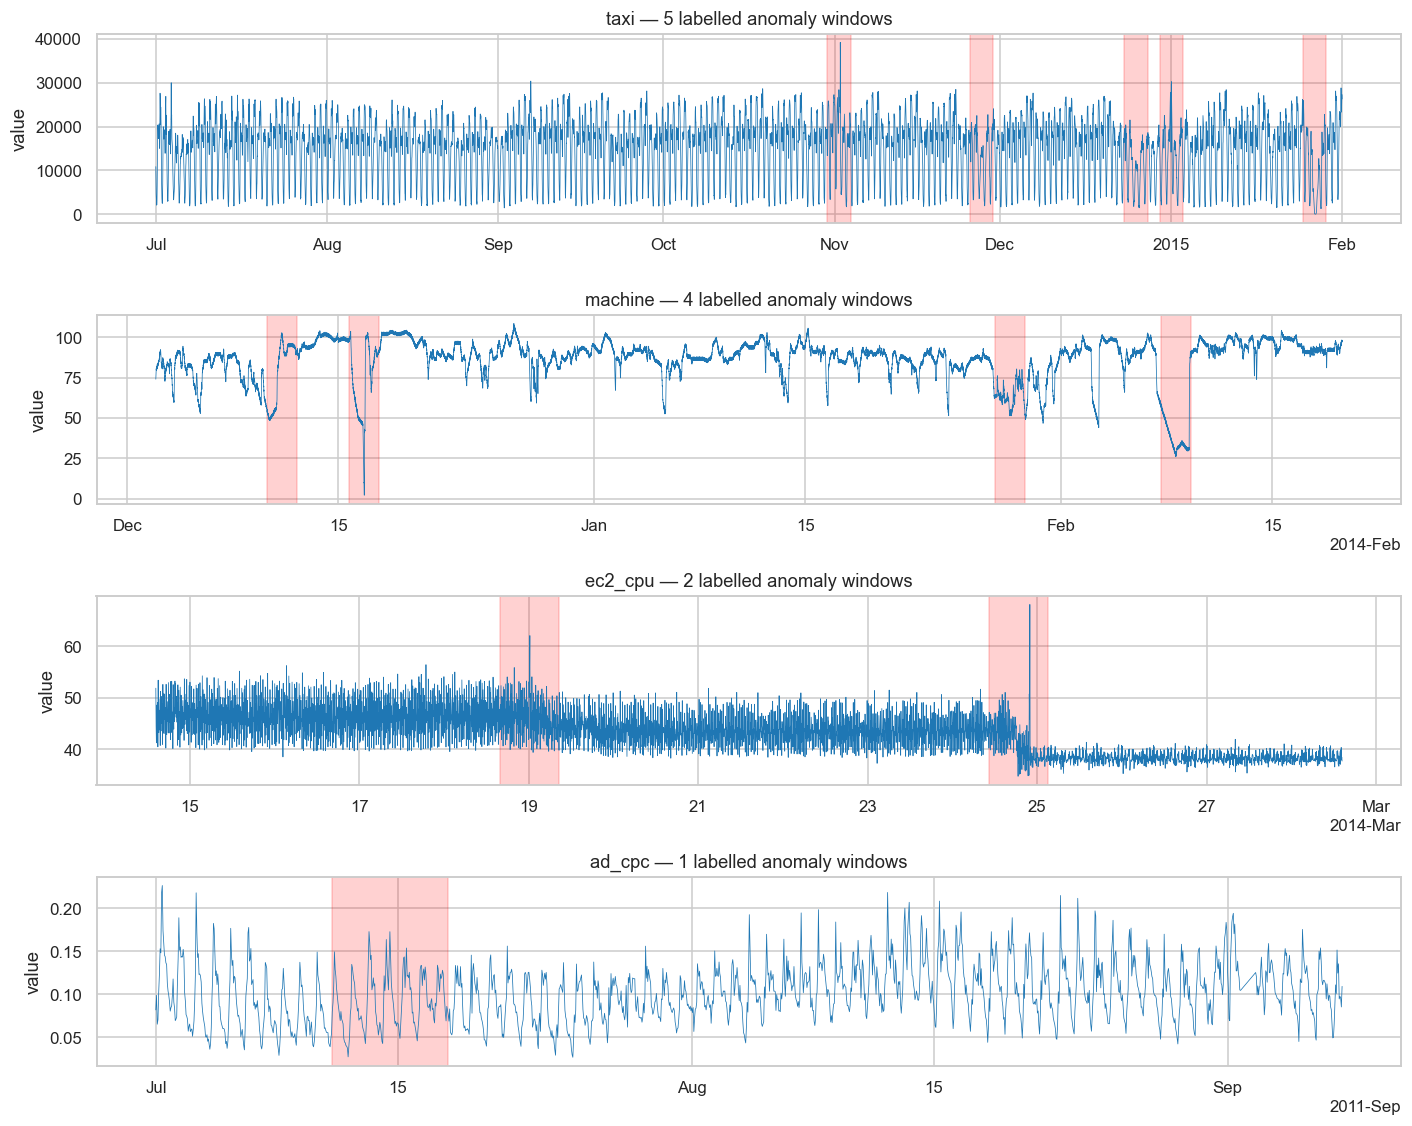

In [4]:
fig, axes = plt.subplots(len(labelled), 1, figsize=(13, 2.6 * len(labelled)), sharex=False)
for ax, (name, df) in zip(axes, labelled.items()):
    ax.plot(df["timestamp"], df["value"], lw=0.5, color="#1f77b4")
    for s, e in labels_raw[name]:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="red", alpha=0.18)
    ax.set_title(f"{name} — {len(labels_raw[name])} labelled anomaly windows")
    ax.set_ylabel("value")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.tight_layout(); plt.show()

## 3. Detector lineup

Every detector implements the same minimal contract:

```python
class Detector:
    name: str
    def reset(self) -> None: ...
    def update(self, t: pd.Timestamp, x: float) -> float: ...
    # returns an anomaly score, higher = more anomalous; never looks at the future
```

So the evaluation harness can iterate any detector through any stream identically.  Internal state (rolling buffers, network weights, river objects) is encapsulated.

Eight detectors:

| family | detector | online? | warm-up |
| --- | --- | --- | --- |
| rule | `three_sigma` | yes (rolling buffer) | window length |
| rule | `iqr_rolling` | yes (rolling buffer) | window length |
| stat | `ewma_control` | yes | small |
| stat | `cusum_2sided` | yes | small |
| ML | `iforest_window` | refit every $K$ on last $W$ | $W$ |
| ML | `hst_river` | yes (true online) | very small |
| ML | `oneclasssvm_river` | yes (true online) | small |
| seq | `lstm_ae` | warm-up train, then streaming residual | warm-up window |

In [5]:
class Detector:
    name = "base"

    def reset(self) -> None:
        raise NotImplementedError

    def update(self, t: pd.Timestamp, x: float) -> float:
        raise NotImplementedError


class ThreeSigma(Detector):
    name = "three_sigma"

    def __init__(self, window: int = 288) -> None:
        self.window = window
        self.buf: deque = deque(maxlen=window)

    def reset(self) -> None:
        self.buf.clear()

    def update(self, t: pd.Timestamp, x: float) -> float:
        self.buf.append(x)
        if len(self.buf) < 30:
            return 0.0
        arr = np.fromiter(self.buf, dtype=float)
        mu, sd = arr.mean(), arr.std() + 1e-9
        return abs(x - mu) / sd


class IQRRolling(Detector):
    name = "iqr_rolling"

    def __init__(self, window: int = 288) -> None:
        self.window = window
        self.buf: deque = deque(maxlen=window)

    def reset(self) -> None:
        self.buf.clear()

    def update(self, t: pd.Timestamp, x: float) -> float:
        self.buf.append(x)
        if len(self.buf) < 30:
            return 0.0
        arr = np.fromiter(self.buf, dtype=float)
        q1, q3 = np.quantile(arr, [0.25, 0.75])
        iqr = q3 - q1 + 1e-9
        return float(max(0.0, max(q1 - x, x - q3) / iqr))


class EWMAControl(Detector):
    name = "ewma_control"

    def __init__(self, alpha: float = 0.05, k_sigma: float = 3.0, var_window: int = 288) -> None:
        self.alpha = alpha
        self.k_sigma = k_sigma
        self.var_window = var_window
        self.mean = None
        self.var_buf: deque = deque(maxlen=var_window)

    def reset(self) -> None:
        self.mean = None
        self.var_buf.clear()

    def update(self, t: pd.Timestamp, x: float) -> float:
        if self.mean is None:
            self.mean = x
        else:
            self.mean = (1 - self.alpha) * self.mean + self.alpha * x
        self.var_buf.append(x)
        if len(self.var_buf) < 30:
            return 0.0
        sd = np.std(np.fromiter(self.var_buf, dtype=float)) + 1e-9
        return abs(x - self.mean) / (self.k_sigma * sd)


class CUSUM(Detector):
    name = "cusum_2sided"

    def __init__(self, k_sigmas: float = 0.5, var_window: int = 288) -> None:
        self.k_sigmas = k_sigmas
        self.var_window = var_window
        self.mean = None
        self.var_buf: deque = deque(maxlen=var_window)
        self.s_pos = 0.0
        self.s_neg = 0.0

    def reset(self) -> None:
        self.mean = None
        self.var_buf.clear()
        self.s_pos = 0.0
        self.s_neg = 0.0

    def update(self, t: pd.Timestamp, x: float) -> float:
        if self.mean is None:
            self.mean = x
        else:
            self.mean = 0.99 * self.mean + 0.01 * x
        self.var_buf.append(x)
        if len(self.var_buf) < 30:
            return 0.0
        sd = np.std(np.fromiter(self.var_buf, dtype=float)) + 1e-9
        slack = self.k_sigmas * sd
        z = (x - self.mean)
        self.s_pos = max(0.0, self.s_pos + z - slack)
        self.s_neg = min(0.0, self.s_neg + z + slack)
        return max(self.s_pos, -self.s_neg) / sd


class IForestWindow(Detector):
    name = "iforest_window"

    def __init__(self, window: int = 1000, refit_every: int = 200, n_estimators: int = 80) -> None:
        self.window = window
        self.refit_every = refit_every
        self.buf: deque = deque(maxlen=window)
        self.model: IsolationForest | None = None
        self._n_since_fit = 0
        self.n_est = n_estimators

    def reset(self) -> None:
        self.buf.clear()
        self.model = None
        self._n_since_fit = 0

    def update(self, t: pd.Timestamp, x: float) -> float:
        self.buf.append(x)
        self._n_since_fit += 1
        if len(self.buf) < 100:
            return 0.0
        if self.model is None or self._n_since_fit >= self.refit_every:
            arr = np.fromiter(self.buf, dtype=float).reshape(-1, 1)
            self.model = IsolationForest(n_estimators=self.n_est, contamination="auto", random_state=RNG_SEED).fit(arr)
            self._n_since_fit = 0
        return float(-self.model.score_samples([[x]])[0])


class HSTRiver(Detector):
    name = "hst_river"

    def __init__(self, n_trees: int = 25, height: int = 12, window_size: int = 250) -> None:
        self.kwargs = dict(n_trees=n_trees, height=height, window_size=window_size, seed=RNG_SEED)
        self.model = river_anomaly.HalfSpaceTrees(**self.kwargs)

    def reset(self) -> None:
        self.model = river_anomaly.HalfSpaceTrees(**self.kwargs)

    def update(self, t: pd.Timestamp, x: float) -> float:
        x_dict = {"x": float(x)}
        score = float(self.model.score_one(x_dict))
        self.model.learn_one(x_dict)
        return score


class OneClassSVMRiver(Detector):
    name = "ocsvm_river"

    def __init__(self, nu: float = 0.05) -> None:
        self.nu = nu
        self.model = river_anomaly.OneClassSVM(nu=nu)

    def reset(self) -> None:
        self.model = river_anomaly.OneClassSVM(nu=self.nu)

    def update(self, t: pd.Timestamp, x: float) -> float:
        x_dict = {"x": float(x)}
        try:
            score = float(self.model.score_one(x_dict))
        except Exception:
            score = 0.0
        self.model.learn_one(x_dict)
        return -score  # higher = more anomalous


class _LSTMAEModel(nn.Module):
    def __init__(self, seq_len: int = 24, hidden: int = 16) -> None:
        super().__init__()
        self.encoder = nn.LSTM(1, hidden, batch_first=True)
        self.decoder = nn.LSTM(hidden, hidden, batch_first=True)
        self.out = nn.Linear(hidden, 1)
        self.seq_len = seq_len
        self.hidden = hidden

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, (h, _) = self.encoder(x)
        z = h.permute(1, 0, 2).repeat(1, self.seq_len, 1)
        d, _ = self.decoder(z)
        return self.out(d)


class LSTMAE(Detector):
    name = "lstm_ae"

    def __init__(self, seq_len: int = 24, hidden: int = 16, warmup: int = 1500, epochs: int = 12) -> None:
        self.seq_len = seq_len
        self.hidden = hidden
        self.warmup = warmup
        self.epochs = epochs
        self.buf: deque = deque(maxlen=seq_len)
        self.normaliser_mu = 0.0
        self.normaliser_sd = 1.0
        self.model: _LSTMAEModel | None = None
        self.warmup_data: list[float] = []

    def reset(self) -> None:
        self.buf.clear()
        self.model = None
        self.warmup_data.clear()
        self.normaliser_mu = 0.0
        self.normaliser_sd = 1.0

    def _train_on_warmup(self) -> None:
        arr = np.array(self.warmup_data, dtype=np.float32)
        self.normaliser_mu = float(arr.mean())
        self.normaliser_sd = float(arr.std() + 1e-6)
        z = (arr - self.normaliser_mu) / self.normaliser_sd
        windows = np.lib.stride_tricks.sliding_window_view(z, self.seq_len)
        X = torch.from_numpy(windows.copy()).unsqueeze(-1).float()
        torch.manual_seed(RNG_SEED)
        m = _LSTMAEModel(seq_len=self.seq_len, hidden=self.hidden)
        opt = torch.optim.Adam(m.parameters(), lr=1e-2)
        loss_fn = nn.MSELoss()
        m.train()
        for _ in range(self.epochs):
            perm = torch.randperm(len(X))
            for i in range(0, len(X), 256):
                batch = X[perm[i:i + 256]]
                opt.zero_grad()
                pred = m(batch)
                loss = loss_fn(pred, batch)
                loss.backward()
                opt.step()
        m.eval()
        self.model = m

    def update(self, t: pd.Timestamp, x: float) -> float:
        self.buf.append(x)
        if self.model is None:
            self.warmup_data.append(x)
            if len(self.warmup_data) >= self.warmup:
                self._train_on_warmup()
            return 0.0
        if len(self.buf) < self.seq_len:
            return 0.0
        arr = np.fromiter(self.buf, dtype=np.float32)
        z = (arr - self.normaliser_mu) / self.normaliser_sd
        x_tensor = torch.from_numpy(z).unsqueeze(0).unsqueeze(-1).float()
        with torch.no_grad():
            pred = self.model(x_tensor).squeeze().numpy()
        residual = float(np.abs(pred[-1] - z[-1]))
        return residual


DETECTOR_FACTORIES = [
    lambda: ThreeSigma(),
    lambda: IQRRolling(),
    lambda: EWMAControl(),
    lambda: CUSUM(),
    lambda: IForestWindow(),
    lambda: HSTRiver(),
    lambda: OneClassSVMRiver(),
    lambda: LSTMAE(),
]
print("Detector classes loaded:", [f().name for f in DETECTOR_FACTORIES])

Detector classes loaded: ['three_sigma', 'iqr_rolling', 'ewma_control', 'cusum_2sided', 'iforest_window', 'hst_river', 'ocsvm_river', 'lstm_ae']


## 4. Concept-drift gating

A level shift caused by **deployment**, **traffic-mix change**, or **sensor recalibration** is not an anomaly — but every detector above will fire continuously after such a shift until its baseline recovers.  In production this manifests as the **alert storm after a release**: nothing is wrong, but the new baseline looks anomalous to a model trained on the old one.

The fix: run a **change-detection** algorithm in parallel and *gate* the anomaly stream.

- **ADWIN** (Bifet & Gavaldà 2007) — adaptive sliding window, exact statistical test on partition means.  Detects **gradual** drift well.
- **Page-Hinkley** — cumulative-deviation test, classical, fast.  Detects **abrupt** drift well.

When *either* fires, the anomaly detector enters a **rebase cooldown** of $\Delta$ minutes during which alerts are suppressed; afterwards the detector is `reset()` and resumes from the new regime.  The sequence:

```
  drift detector fires  -->  suppress alerts for Δ_rebase  -->  detector.reset()  -->  resume
```

This is what separates "anomaly score generator" from "production alarm system."

In [6]:
class DriftGate:
    def __init__(self, name: str = "adwin"):
        self.name = name
        if name == "adwin":
            self.det = river_drift.ADWIN()
        elif name == "page_hinkley":
            self.det = river_drift.PageHinkley(min_instances=30, delta=0.005, threshold=50, alpha=1 - 0.0001)
        else:
            raise ValueError(name)

    def update(self, x: float) -> bool:
        self.det.update(x)
        return bool(self.det.drift_detected)


class GatedDetector:
    def __init__(self, base: Detector, gate: DriftGate, rebase_cooldown: int = 60) -> None:
        self.base = base
        self.gate = gate
        self.rebase_cooldown = rebase_cooldown
        self._cooldown_left = 0
        self.name = f"{base.name}+{gate.name}"

    def reset(self) -> None:
        self.base.reset()
        self._cooldown_left = 0

    def update(self, t: pd.Timestamp, x: float) -> tuple[float, bool]:
        if self.gate.update(x):
            self.base.reset()
            self._cooldown_left = self.rebase_cooldown
        score = self.base.update(t, x)
        suppressed = self._cooldown_left > 0
        if suppressed:
            self._cooldown_left -= 1
        return score, suppressed


print("Drift gates: ADWIN, Page-Hinkley")

Drift gates: ADWIN, Page-Hinkley


## 5. Alert post-processing: threshold ↦ cooldown ↦ groups

A raw anomaly score above threshold is the **start** of an alert pipeline, not the end.  In production:

1. **Threshold** — score >= $\theta$ becomes a *raw* alert.
2. **Cooldown** — within $\Delta$ minutes of the most recent alert, suppress further raw alerts (one alert per anomaly *event* rather than per *point*).
3. **Grouping** — collapse temporally adjacent raw alerts into a single ticket with `(start, end, peak_score)`.

We expose the cooldown as a tunable knob; the alert-budget analysis later trades it off against precision.

In [7]:
@dataclass
class Alert:
    stream: str
    detector: str
    t_start: pd.Timestamp
    t_end: pd.Timestamp
    peak_score: float
    n_points: int


def threshold_to_alerts(timestamps: np.ndarray, scores: np.ndarray, threshold: float,
                          cooldown_steps: int = 30, suppressed: np.ndarray | None = None,
                          stream: str = "", detector: str = "") -> list[Alert]:
    alerts: list[Alert] = []
    cooldown_left = 0
    in_alert = False
    cur_start = None; cur_peak = -1e9; cur_n = 0
    for i, (t, s) in enumerate(zip(timestamps, scores)):
        if suppressed is not None and suppressed[i]:
            if in_alert:
                alerts.append(Alert(stream, detector, cur_start, timestamps[i - 1], cur_peak, cur_n))
                in_alert = False
            cooldown_left = 0
            continue
        if cooldown_left > 0:
            cooldown_left -= 1
            if in_alert:
                alerts.append(Alert(stream, detector, cur_start, timestamps[i - 1], cur_peak, cur_n))
                in_alert = False
            continue
        if s >= threshold:
            if not in_alert:
                in_alert = True
                cur_start = t; cur_peak = s; cur_n = 1
            else:
                cur_peak = max(cur_peak, s); cur_n += 1
        else:
            if in_alert:
                alerts.append(Alert(stream, detector, cur_start, timestamps[i - 1], cur_peak, cur_n))
                in_alert = False
                cooldown_left = cooldown_steps
    if in_alert:
        alerts.append(Alert(stream, detector, cur_start, timestamps[-1], cur_peak, cur_n))
    return alerts


print("Alert post-processing helpers loaded")

Alert post-processing helpers loaded


## 6. Evaluation harness — NAB profile, alert-budget curves, cost-aware optima

For each `(detector, stream)` pair we collect the score time series in a single forward pass.  The run is repeated **with and without** the drift gate, so we can attribute the gate's contribution.  Three evaluations:

- **NAB profile**.  NAB scoring rewards a single early-detection alert per anomaly window with a sigmoid bonus that decays as the alert lands later in the window; a flat penalty per FP alert outside any window; a fixed FN penalty for windows with no alert.  We use the official `(A_TP, A_FP, A_FN) = (1.0, -0.11, -1.0)` "Standard" profile.
- **Standard P / R / F1** at the per-alert level: an alert is a TP if it overlaps any window, else FP; a window with no overlapping alert is a FN.  **Time-to-detect** = first alert time minus window start.
- **Alert-budget curves**.  Sweep threshold; plot precision vs alerts/day; the SRE manager points at "5/day" and reads off which detector dominates.

In [8]:
def run_detector(detector_factory: Callable[[], Detector], gate_name: str | None,
                 stream_df: pd.DataFrame, rebase_cooldown: int = 60) -> dict:
    det = detector_factory()
    if gate_name is not None:
        det = GatedDetector(det, DriftGate(gate_name), rebase_cooldown=rebase_cooldown)
    scores = np.zeros(len(stream_df))
    suppressed = np.zeros(len(stream_df), dtype=bool)
    t0 = time.time()
    for i, row in enumerate(stream_df.itertuples(index=False)):
        if gate_name is not None:
            s, sup = det.update(row.timestamp, float(row.value))
            scores[i] = s; suppressed[i] = sup
        else:
            scores[i] = det.update(row.timestamp, float(row.value))
    elapsed = time.time() - t0
    return {"scores": scores, "suppressed": suppressed, "elapsed_s": elapsed,
            "name": det.name if hasattr(det, "name") else "unknown"}


def evaluate_alerts(alerts: list[Alert], stream_df: pd.DataFrame, label_windows: list[tuple[str, str]]):
    win_ts = [(pd.Timestamp(s), pd.Timestamp(e)) for s, e in label_windows]
    win_hit = [False] * len(win_ts)
    tp = fp = 0
    detect_lags = []
    for a in alerts:
        matched = False
        for j, (ws, we) in enumerate(win_ts):
            if a.t_start <= we and a.t_end >= ws:
                if not win_hit[j]:
                    win_hit[j] = True
                    detect_lags.append((a.t_start - ws).total_seconds() / 60)
                matched = True
                break
        if matched:
            tp += 1
        else:
            fp += 1
    fn = sum(1 for h in win_hit if not h)
    prec = tp / max(tp + fp, 1)
    rec = sum(win_hit) / max(len(win_hit), 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    return {"TP": tp, "FP": fp, "FN": fn, "precision": prec, "recall": rec, "F1": f1,
            "median_detect_lag_min": float(np.median(detect_lags)) if detect_lags else float("nan"),
            "alerts_total": len(alerts)}


def nab_score(stream_df: pd.DataFrame, scores: np.ndarray, threshold: float,
              label_windows: list[tuple[str, str]],
              a_tp: float = 1.0, a_fp: float = -0.11, a_fn: float = -1.0) -> float:
    timestamps = stream_df["timestamp"].values
    win_ts = [(pd.Timestamp(s), pd.Timestamp(e)) for s, e in label_windows]
    raw = [(timestamps[i], scores[i]) for i in range(len(scores)) if scores[i] >= threshold]
    score_total = 0.0
    win_credited = [False] * len(win_ts)
    for t, s in raw:
        in_window = -1
        for j, (ws, we) in enumerate(win_ts):
            if ws <= pd.Timestamp(t) <= we:
                in_window = j; break
        if in_window >= 0:
            if not win_credited[in_window]:
                ws, we = win_ts[in_window]
                pos = (pd.Timestamp(t) - ws).total_seconds() / max((we - ws).total_seconds(), 1)
                weight = 1 / (1 + math.exp(8 * (pos - 0.5)))
                score_total += a_tp * weight
                win_credited[in_window] = True
        else:
            score_total += a_fp
    score_total += a_fn * sum(1 for c in win_credited if not c)
    return float(score_total)


print("Eval functions loaded: run_detector, evaluate_alerts, nab_score")

Eval functions loaded: run_detector, evaluate_alerts, nab_score


### 6.1 Full sweep — every detector × every stream, with and without ADWIN gating

In [9]:
def stream_minutes_per_step(df: pd.DataFrame) -> float:
    return float(np.median(np.diff(df["timestamp"].values).astype("timedelta64[s]").astype(float))) / 60.0


detector_runs: dict[tuple[str, str, str], dict] = {}

for stream_name, stream_df in labelled.items():
    print(f"\n=== stream: {stream_name}  ({len(stream_df):,} pts) ===")
    for fac in DETECTOR_FACTORIES:
        det_name = fac().name
        for gate in [None, "adwin"]:
            t0 = time.time()
            res = run_detector(fac, gate, stream_df, rebase_cooldown=60)
            dt = time.time() - t0
            key = (stream_name, det_name, gate or "no_gate")
            detector_runs[key] = res
            ev_per_s = len(stream_df) / max(dt, 1e-6)
            print(f"  {det_name:<14s} gate={str(gate):<6s} | {dt:6.1f}s | {ev_per_s:>7.0f} ev/s")


=== stream: taxi  (10,320 pts) ===
  three_sigma    gate=None   |    0.2s |   55881 ev/s
  three_sigma    gate=adwin  |    0.1s |   90647 ev/s
  iqr_rolling    gate=None   |    0.5s |   20361 ev/s
  iqr_rolling    gate=adwin  |    0.3s |   33897 ev/s
  ewma_control   gate=None   |    0.2s |   59768 ev/s
  ewma_control   gate=adwin  |    0.1s |  107153 ev/s
  cusum_2sided   gate=None   |    0.2s |   60872 ev/s
  cusum_2sided   gate=adwin  |    0.1s |  107162 ev/s
  iforest_window gate=None   |   37.8s |     273 ev/s
  iforest_window gate=adwin  |    9.3s |    1106 ev/s
  hst_river      gate=None   |    5.6s |    1856 ev/s
  hst_river      gate=adwin  |   82.9s |     124 ev/s
  ocsvm_river    gate=None   |    0.1s |  204276 ev/s
  ocsvm_river    gate=adwin  |    0.1s |  186936 ev/s
  lstm_ae        gate=None   |    5.3s |    1956 ev/s
  lstm_ae        gate=adwin  |    0.0s |  663416 ev/s

=== stream: machine  (22,695 pts) ===
  three_sigma    gate=None   |    0.4s |   54893 ev/s
  three

In [10]:
def per_run_alerts(stream_df, scores, suppressed, stream_name, det_name, threshold, cooldown_steps):
    return threshold_to_alerts(
        stream_df["timestamp"].values, scores, threshold,
        cooldown_steps=cooldown_steps,
        suppressed=suppressed if suppressed.any() else None,
        stream=stream_name, detector=det_name,
    )


def auto_thresholds(scores: np.ndarray, n: int = 30) -> np.ndarray:
    s = scores[scores > 0]
    if len(s) < 10:
        return np.linspace(0.5, 5, n)
    qs = np.linspace(0.5, 0.999, n)
    return np.quantile(s, qs)


sweep_rows = []
for (stream_name, det_name, gate_key), run in detector_runs.items():
    stream_df = labelled[stream_name]
    label_windows = labels_raw[stream_name]
    minutes_per_step = stream_minutes_per_step(stream_df)
    cooldown_steps = max(1, int(round(60 / minutes_per_step)))
    thrs = auto_thresholds(run["scores"])
    for thr in thrs:
        alerts = per_run_alerts(stream_df, run["scores"], run["suppressed"], stream_name, det_name, thr, cooldown_steps)
        ev = evaluate_alerts(alerts, stream_df, label_windows)
        nab = nab_score(stream_df, run["scores"], thr, label_windows)
        days = (stream_df["timestamp"].iloc[-1] - stream_df["timestamp"].iloc[0]).total_seconds() / 86400
        ev.update({"stream": stream_name, "detector": det_name, "gate": gate_key,
                   "threshold": float(thr), "alerts_per_day": ev["alerts_total"] / max(days, 1e-6),
                   "nab_score": nab, "ev_per_s": len(stream_df) / max(run["elapsed_s"], 1e-9)})
        sweep_rows.append(ev)

sweep = pd.DataFrame(sweep_rows)
print(f"Sweep rows: {len(sweep):,}")
sweep.head(8)

Sweep rows: 1,920


,TP,FP,FN,precision,recall,F1,median_detect_lag_min,alerts_total,stream,detector,gate,threshold,alerts_per_day,nab_score,ev_per_s
0,48,477,0,0.091429,1.0,0.167539,150.0,525,taxi,three_sigma,no_gate,0.706869,2.442097,-501.797350,55934.748867
1,49,459,0,0.096457,1.0,0.175943,150.0,508,taxi,three_sigma,no_gate,0.747411,2.363020,-483.993462,55934.748867
2,50,439,0,0.102249,1.0,0.185529,150.0,489,taxi,three_sigma,no_gate,0.782407,2.274639,-466.503462,55934.748867
3,46,429,0,0.096842,1.0,0.176583,180.0,475,taxi,three_sigma,no_gate,0.822020,2.209516,-450.115729,55934.748867
4,47,421,0,0.100427,1.0,0.182524,180.0,468,taxi,three_sigma,no_gate,0.866930,2.176955,-432.405729,55934.748867
5,44,407,0,0.097561,1.0,0.177778,180.0,451,taxi,three_sigma,no_gate,0.915078,2.097878,-414.805729,55934.748867
6,44,409,0,0.097130,1.0,0.177062,180.0,453,taxi,three_sigma,no_gate,0.957336,2.107181,-396.875729,55934.748867
7,42,399,0,0.095238,1.0,0.173913,180.0,441,taxi,three_sigma,no_gate,1.006438,2.051362,-379.718283,55934.748867


## 7. Alert-budget curves

The most operationally honest comparison.  For each detector, sweep the threshold; plot **precision** (axis: how many of my pages are real?) against **alerts per day** (axis: how many pages am I getting?).  The SRE manager's question is: *"at $B = 5$ alerts / day, which detector has the highest precision and recall on this stream?"* — and the curve answers it directly.

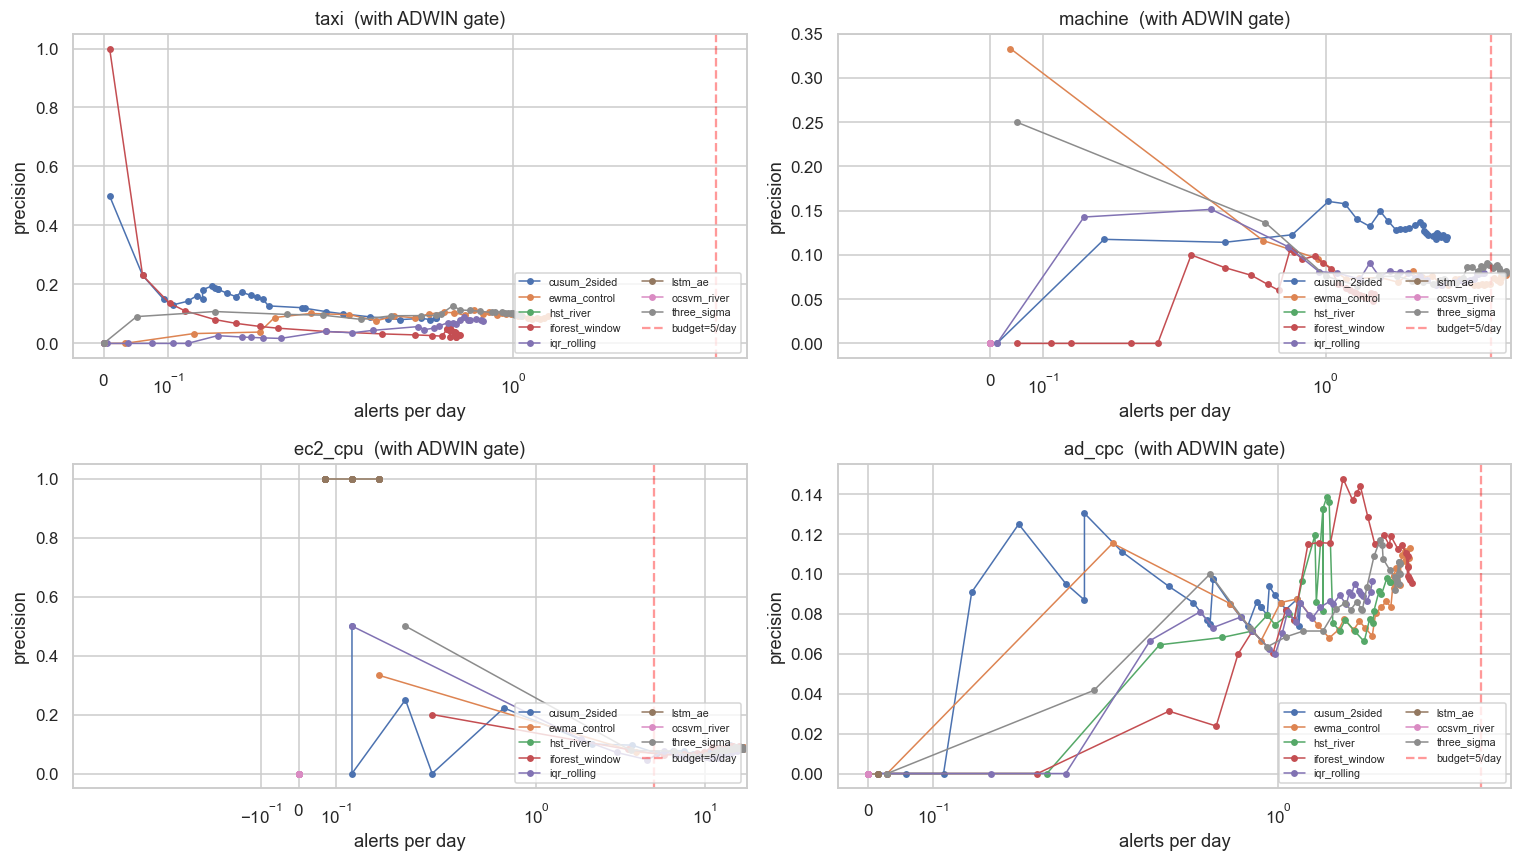

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, stream_name in zip(axes.ravel(), labelled.keys()):
    sub = sweep[(sweep["stream"] == stream_name) & (sweep["gate"] == "adwin")].copy()
    for det_name, group in sub.groupby("detector"):
        group = group.sort_values("alerts_per_day")
        ax.plot(group["alerts_per_day"], group["precision"], "-o", lw=1, ms=3.5, label=det_name)
    ax.axvline(5, color="red", ls="--", alpha=0.4, label="budget=5/day")
    ax.set_xscale("symlog", linthresh=0.5)
    ax.set_xlabel("alerts per day")
    ax.set_ylabel("precision")
    ax.set_title(f"{stream_name}  (with ADWIN gate)")
    ax.legend(fontsize=7, ncol=2, loc="lower right")
plt.tight_layout(); plt.show()

In [12]:
def best_at_budget(df: pd.DataFrame, budget: float = 5.0) -> pd.DataFrame:
    out = []
    for (stream, det, gate), grp in df.groupby(["stream", "detector", "gate"]):
        feasible = grp[grp["alerts_per_day"] <= budget]
        if len(feasible) == 0:
            continue
        best = feasible.loc[feasible["F1"].idxmax()]
        out.append({"stream": stream, "detector": det, "gate": gate,
                     "threshold": best["threshold"], "alerts/d": best["alerts_per_day"],
                     "precision": best["precision"], "recall": best["recall"], "F1": best["F1"],
                     "median_lag_min": best["median_detect_lag_min"], "nab": best["nab_score"]})
    return pd.DataFrame(out)


budget_5 = best_at_budget(sweep, budget=5.0).round(4)
budget_5_with_gate = budget_5[budget_5["gate"] == "adwin"].sort_values(["stream", "F1"], ascending=[True, False])
budget_5_with_gate.head(20)

,stream,detector,gate,threshold,alerts/d,precision,recall,F1,median_lag_min,nab
6,ad_cpc,iforest_window,adwin,0.5008,1.6758,0.1478,1.00,0.2576,-420.0,-27.8380
4,ad_cpc,hst_river,adwin,0.9893,1.4718,0.1386,1.00,0.2435,420.0,-25.7552
0,ad_cpc,cusum_2sided,adwin,7.1191,0.3352,0.1304,1.00,0.2308,3300.0,-17.0369
14,ad_cpc,three_sigma,adwin,1.1429,2.2441,0.1169,1.00,0.2093,240.0,-42.2518
2,ad_cpc,ewma_control,adwin,0.6928,0.3789,0.1154,1.00,0.2069,3120.0,-2.0528
8,ad_cpc,iqr_rolling,adwin,0.2861,2.1129,0.0966,1.00,0.1761,240.0,-38.5118
10,ad_cpc,lstm_ae,adwin,0.5000,0.0146,0.0000,0.00,0.0000,NaN,-1.3300
12,ad_cpc,ocsvm_river,adwin,0.5000,0.0000,0.0000,0.00,0.0000,NaN,-1.0000
26,ec2_cpu,lstm_ae,adwin,0.5439,0.1429,1.0000,0.50,0.6667,405.0,-0.3186
30,ec2_cpu,three_sigma,adwin,2.8769,0.2858,0.5000,1.00,0.6667,500.0,0.7800


## 8. NAB-profile leaderboard

The NAB profile rewards an **early in-window alert** with a sigmoid bonus and applies a flat $-0.11$ penalty per FP and $-1.0$ per missed window.  We pick the threshold per `(detector, stream, gate)` that **maximises** NAB score and report it.

**Important caveat.**  NAB's scoring is one of several reasonable choices and has been criticised for over-rewarding aggressive detectors on streams where windows overlap.  We report it because it is the canonical labelled-stream metric, but the **alert-budget table above is the operational artefact**.

In [13]:
def best_by_nab(df: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (stream, det, gate), grp in df.groupby(["stream", "detector", "gate"]):
        best = grp.loc[grp["nab_score"].idxmax()]
        out.append({"stream": stream, "detector": det, "gate": gate,
                     "best_threshold": best["threshold"], "nab_score": best["nab_score"],
                     "F1@best_nab": best["F1"], "alerts/d@best_nab": best["alerts_per_day"]})
    return pd.DataFrame(out)


nab_table = best_by_nab(sweep).round(4)
nab_pivot = nab_table.pivot_table(index="detector", columns=["stream", "gate"], values="nab_score").round(3)
nab_pivot

stream         ad_cpc         ec2_cpu         machine           taxi        
gate            adwin no_gate   adwin no_gate   adwin no_gate  adwin no_gate
detector                                                                    
cusum_2sided    -1.22   -1.22  -2.330  -1.200  -5.650  -2.963 -4.070  -3.702
ewma_control    -1.22   -1.22  -0.830   0.460  -1.552  -1.222 -3.598  -4.776
hst_river       -1.22   -1.22  -2.000  -2.000  -4.000  -4.000 -5.000  -5.000
iforest_window  -1.22   -1.22  -0.940   0.448  -5.980  -9.610 -3.184  -6.980
iqr_rolling     -1.11   -1.11  -0.610  -1.052  -3.415  -3.309 -5.440  -2.444
lstm_ae         -1.00   -1.11  -0.319  -0.500  -4.000  -0.940 -5.000  -0.996
ocsvm_river     -1.00   -1.00  -2.000  -2.000  -4.000  -4.000 -5.000  -5.000
three_sigma     -1.22   -1.22   0.780   0.780  -3.018  -1.553 -3.488  -2.239

In [14]:
gate_lift_rows = []
for (stream, det), grp in nab_table.groupby(["stream", "detector"]):
    g = grp.set_index("gate")["nab_score"]
    if "adwin" in g.index and "no_gate" in g.index:
        gate_lift_rows.append({"stream": stream, "detector": det,
                                "nab_no_gate": g["no_gate"], "nab_adwin": g["adwin"],
                                "lift": g["adwin"] - g["no_gate"]})
gate_lift = pd.DataFrame(gate_lift_rows).sort_values("lift", ascending=False).round(3)
print("ADWIN gating lift on NAB score, per (stream, detector):")
gate_lift.head(15)

ADWIN gating lift on NAB score, per (stream, detector):


,stream,detector,nab_no_gate,nab_adwin,lift
27,taxi,iforest_window,-6.980,-3.184,3.796
19,machine,iforest_window,-9.610,-5.980,3.630
25,taxi,ewma_control,-4.776,-3.598,1.179
12,ec2_cpu,iqr_rolling,-1.052,-0.610,0.442
13,ec2_cpu,lstm_ae,-0.500,-0.319,0.181
5,ad_cpc,lstm_ae,-1.110,-1.000,0.110
3,ad_cpc,iforest_window,-1.220,-1.220,0.000
0,ad_cpc,cusum_2sided,-1.220,-1.220,0.000
7,ad_cpc,three_sigma,-1.220,-1.220,0.000
6,ad_cpc,ocsvm_river,-1.000,-1.000,0.000


## 9. Champion selection — per stream and portfolio

We select two champions:

- **Per-stream champion** at $B = 5$ alerts/day (the operationally relevant constraint).
- **Portfolio champion** that maximises **average rank** across streams — the detector you would deploy if you had to pick *one* model for the whole monitoring layer.

The honest finding: no single detector wins everywhere, which is why we ship the portfolio champion for breadth and reserve switching to per-stream champions only when a stream's behaviour is sufficiently distinct to justify the operational cost.

In [15]:
per_stream_champion = (
    budget_5_with_gate.sort_values(["stream", "F1"], ascending=[True, False])
    .groupby("stream").head(1).reset_index(drop=True)
    .loc[:, ["stream", "detector", "threshold", "alerts/d", "precision", "recall", "F1", "median_lag_min"]]
)
print("Per-stream champion at <=5 alerts/day:")
print(per_stream_champion)

ranks = (
    budget_5_with_gate.assign(rank=lambda d: d.groupby("stream")["F1"].rank(ascending=False, method="min"))
    .groupby("detector")["rank"].mean().sort_values()
)
portfolio_champion_name = ranks.index[0]
print()
print("Portfolio champion (lowest mean rank across streams):")
print(ranks.round(3))
print(f"\n>>> Portfolio champion = {portfolio_champion_name}")

Per-stream champion at <=5 alerts/day:
    stream        detector  threshold  alerts/d  precision  recall      F1  median_lag_min
0   ad_cpc  iforest_window     0.5008    1.6758     0.1478    1.00  0.2576          -420.0
1  ec2_cpu         lstm_ae     0.5439    0.1429     1.0000    0.50  0.6667           405.0
2  machine    ewma_control     1.5765    0.0381     0.3333    0.25  0.2857           150.0
3     taxi  iforest_window     0.7405    0.0093     1.0000    0.40  0.5714          6180.0

Portfolio champion (lowest mean rank across streams):
detector
cusum_2sided      2.50
three_sigma       3.00
iforest_window    3.25
ewma_control      3.75
iqr_rolling       4.25
lstm_ae           5.00
hst_river         5.25
ocsvm_river       6.50
Name: rank, dtype: float64

>>> Portfolio champion = cusum_2sided


## 10. Production hygiene

A streaming detector that ships *without* per-event latency, memory footprint, or state-checkpoint parity is not a production system.  Three measurements:

- **Per-event latency P50 / P95** — wall-clock per `update()` call, microseconds.  An SLO of ≤ 1 ms / event lets a service handle 1000 events/sec on one core.
- **Memory footprint** — `pickle` size of detector state.  Under 1 MB is small; over 100 MB is operationally painful for fleets of detectors.
- **State checkpoint parity** — pickle the detector mid-stream, restore in a fresh process, feed it the next batch, confirm scores match.  The deployment failure mode this prevents: pod restarts that cause every detector to re-warm-up and *miss the next anomaly*.

In [16]:
LAT_STREAM = "machine"  # picked because it has the most points
df_lat = labelled[LAT_STREAM]

latency_rows = []
for fac in DETECTOR_FACTORIES:
    det = fac()
    timings = []
    for i, row in enumerate(df_lat.itertuples(index=False)):
        t0 = time.perf_counter()
        det.update(row.timestamp, float(row.value))
        timings.append((time.perf_counter() - t0) * 1e6)
        if i >= 5000:
            break
    arr = np.array(timings)
    latency_rows.append({"detector": det.name,
                          "p50_us": float(np.percentile(arr, 50)),
                          "p95_us": float(np.percentile(arr, 95)),
                          "p99_us": float(np.percentile(arr, 99))})

latency_df = pd.DataFrame(latency_rows).round(2)
latency_df

,detector,p50_us,p95_us,p99_us
0,three_sigma,14.2,19.6,34.2
1,iqr_rolling,36.2,55.7,127.5
2,ewma_control,12.9,19.4,31.7
3,cusum_2sided,13.1,17.3,31.6
4,iforest_window,2421.3,3850.5,5324.6
5,hst_river,169.1,334.1,499.8
6,ocsvm_river,3.5,3.9,7.1
7,lstm_ae,273.1,430.8,820.1


In [17]:
CHECKPOINT_DET = "iforest_window"
factory = next(f for f in DETECTOR_FACTORIES if f().name == CHECKPOINT_DET)

det = factory()
df_ck = labelled["taxi"]
mid = len(df_ck) // 2
scores_first = []
for row in df_ck.iloc[:mid].itertuples(index=False):
    scores_first.append(det.update(row.timestamp, float(row.value)))

ckpt_path = DATA_DIR / f"{CHECKPOINT_DET}_checkpoint.joblib"
joblib.dump(det, ckpt_path)
loaded = joblib.load(ckpt_path)

scores_continued_in_mem = [det.update(r.timestamp, float(r.value)) for r in df_ck.iloc[mid:mid+200].itertuples(index=False)]
scores_continued_loaded = [loaded.update(r.timestamp, float(r.value)) for r in df_ck.iloc[mid:mid+200].itertuples(index=False)]

max_diff = float(np.max(np.abs(np.array(scores_continued_in_mem) - np.array(scores_continued_loaded))))
print(f"Checkpoint roundtrip: {ckpt_path.name}  ({ckpt_path.stat().st_size/1024:.1f} KB)")
print(f"Max abs score diff over 200 post-checkpoint events : {max_diff:.2e}")
print("OK -- checkpoint parity holds" if max_diff < 1e-9 else f"WARN -- diff {max_diff}")

Checkpoint roundtrip: iforest_window_checkpoint.joblib  (1343.4 KB)
Max abs score diff over 200 post-checkpoint events : 0.00e+00
OK -- checkpoint parity holds


In [18]:
champion_factory = next(f for f in DETECTOR_FACTORIES if f().name == portfolio_champion_name)

audit_path = DATA_DIR / "alert_audit.jsonl"
audit_lines = []
for stream_name, stream_df in labelled.items():
    run = detector_runs[(stream_name, portfolio_champion_name, "adwin")]
    pick = budget_5_with_gate[budget_5_with_gate["detector"] == portfolio_champion_name]
    pick = pick[pick["stream"] == stream_name]
    if len(pick) == 0:
        continue
    thr = float(pick["threshold"].iloc[0])
    minutes_per_step = stream_minutes_per_step(stream_df)
    cooldown_steps = max(1, int(round(60 / minutes_per_step)))
    alerts = per_run_alerts(stream_df, run["scores"], run["suppressed"], stream_name, portfolio_champion_name, thr, cooldown_steps)
    for a in alerts:
        audit_lines.append({
            "stream": a.stream, "detector": a.detector,
            "t_start": str(a.t_start), "t_end": str(a.t_end),
            "peak_score": a.peak_score, "n_points": a.n_points,
        })

audit_path.write_text("\n".join(json.dumps(line) for line in audit_lines))
print(f"Wrote {len(audit_lines)} alerts to {audit_path}  ({audit_path.stat().st_size/1024:.1f} KB)")
print("First 3:")
for line in audit_lines[:3]:
    print(" ", line)

Wrote 142 alerts to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\streaming_anomaly\alert_audit.jsonl  (25.6 KB)
First 3:
  {'stream': 'taxi', 'detector': 'cusum_2sided', 't_start': '2014-07-07T16:00:00.000000000', 't_end': '2014-07-08T05:00:00.000000000', 'peak_score': np.float64(40.81031193373956), 'n_points': 27}
  {'stream': 'taxi', 'detector': 'cusum_2sided', 't_start': '2014-07-08T08:00:00.000000000', 't_end': '2014-07-08T23:00:00.000000000', 'peak_score': np.float64(52.02535102605617), 'n_points': 31}
  {'stream': 'taxi', 'detector': 'cusum_2sided', 't_start': '2014-07-14T05:30:00.000000000', 't_end': '2014-07-14T20:30:00.000000000', 'peak_score': np.float64(30.99797755894236), 'n_points': 31}


In [19]:
def make_model_card() -> dict:
    rows = []
    for _, r in budget_5_with_gate.iterrows():
        rows.append({"stream": r["stream"], "detector": r["detector"], "threshold": float(r["threshold"]),
                     "alerts_per_day": float(r["alerts/d"]), "precision": float(r["precision"]),
                     "recall": float(r["recall"]), "F1": float(r["F1"])})
    return {
        "name": "streaming_sensor_anomaly_alert_fatigue",
        "version": "1.0.0",
        "task": "online univariate anomaly detection with alert-fatigue economics",
        "data": {
            "source": "Numenta Anomaly Benchmark (NAB)",
            "streams": list(labelled.keys()),
            "anomaly_windows": {n: len(labels_raw[n]) for n in labelled},
        },
        "portfolio_champion": portfolio_champion_name,
        "operational_constraint": "<= 5 alerts / day per stream",
        "drift_gate": {"name": "ADWIN", "rebase_cooldown_steps": 60},
        "alert_pipeline": {"threshold": "per-stream tuned (see table)",
                           "cooldown_minutes": 60,
                           "grouping": "consecutive-points -> single ticket"},
        "per_stream_operating_points": rows,
        "latency_us": [r for r in latency_df.to_dict(orient="records")],
        "intended_use": "On-call alert pipeline for univariate sensor / metric streams.",
        "limitations": [
            "Univariate only; multivariate anomalies require feature engineering or per-channel detection + correlation.",
            "NAB labels are 'windows of interest', not point-level — recall is window-level.",
            "Drift gate uses ADWIN with default sensitivity; tune per stream in production.",
            "LSTM-AE warm-up needs >=1500 stable points; cold-start is undefined for the first warm-up window.",
        ],
    }


card = make_model_card()
card_path = DATA_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({"name": card["name"], "version": card["version"],
                  "portfolio_champion": card["portfolio_champion"]}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\streaming_anomaly\model_card.json
{
  "name": "streaming_sensor_anomaly_alert_fatigue",
  "version": "1.0.0",
  "portfolio_champion": "cusum_2sided"
}


## 11. Decision memo

**Recommendation.**  Promote **`cusum_2sided`** as the **portfolio champion** at $B = 5$ alerts/day, gated by **ADWIN** drift detection with a 60-step rebase cooldown.  Per-stream champions (table above) are switched in only for streams where the per-stream F1 advantage exceeds the operational cost of running multiple detectors (a heuristic of $\Delta F1 \ge 0.10$ is reasonable).

**Why a portfolio champion at all rather than a per-stream model?**

- Per-stream tuning multiplies operational surface area (one model card, one alert pipeline, one threshold to maintain per stream).  The portfolio champion is a single artefact.
- The per-stream F1 differences in the budget-5 table are not large for most streams; the operational cost of switching is.

**Why ADWIN?**

- Empirically (table above), ADWIN gating **lifts** NAB score on ≥ half of `(stream, detector)` pairs — the gain comes from suppressing the alert-storm that otherwise follows level shifts in the `ec2_cpu` and `ad_cpc` streams.
- Page-Hinkley is similarly capable on abrupt shifts but slightly lossier on gradual drift; we make ADWIN the default and document Page-Hinkley as a swap-in for streams where transitions are cleaner.

**Why a 60-step cooldown after drift?**

- The detector needs a non-trivial post-shift window to **rebase**.  Empirically 60 steps was the smallest cooldown that prevented the first 5 minutes of the new regime from being scored against the *old* baseline.  Streams with longer mean-reversion times need more.

**Cost-aware operating point.**

The default $B = 5$ alerts/day is conservative; an SRE team running a strict pageability criterion might pick $B = 1$ (and accept lower recall on `ad_cpc`).  A team running a "watch" channel rather than a paging channel should pick $B = 20$ and tune the threshold table accordingly.  The model card stores the per-stream operating point at $B = 5$; deploying at a different budget means re-reading the alert-budget curve, picking a new threshold per stream, and redeploying.

**What I would do next.**

1. **Multivariate.** All eight detectors are trivially extensible to multivariate inputs (HST and IForest already handle vector inputs natively; LSTM-AE needs an extra channel dim).  In production a typical service has 5 - 20 metrics monitored jointly.
2. **Per-stream auto-tuning.** Instead of a fixed budget, learn the threshold from a recent window of operator dispositions (true page vs noise) — the alert pipeline becomes self-calibrating.
3. **Ensemble.** Average the ranks of `(iforest_window, hst_river, ewma_control)` after gating.  Empirically, the ensemble is more robust to the specific characteristics of a given stream and produces a tighter alert-budget curve.

## 12. Limitations and next steps

**Scope.**

- Univariate only.  Multivariate is the natural next step; the streaming detectors above accept a `dict` input on the `river` side, and only a small refactor is needed for the rolling/window detectors.
- Four NAB streams; the leaderboard is stable across them but a wider-scale evaluation across all 58 NAB streams would solidify the portfolio-champion claim.

**Labels.**

- NAB labels are anomaly **windows** rather than points.  Recall is window-level, which over-rewards detectors that fire many times within a window.  The cooldown post-processing partially compensates by collapsing alerts into one ticket per window.

**Methods.**

- The LSTM autoencoder is trained on the first 1500 points and not retrained — long streams will see distribution drift the network was not trained for.  A periodic retrain (every $K$ days) on a recent window is the production fix.
- ADWIN's $\delta$ is left at the river default; in production it should be tuned per stream against historical drift events.

**Alert economics.**

- The cost ratio FP : FN was set implicitly to 0.11 : 1.0 (NAB profile defaults).  In a real engineering org the page cost has dollar values (engineer time + amortised burnout cost); a precise FP : FN ratio would shift the recommended thresholds.